# EfficientNetB2 para clasificacion de aves CUB-200-2011


## 1. Importar librerias y configurar parametros


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.efficientnet import EfficientNetB2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
DATASET_NAME = "caltech_birds2011"
IMG_SIZE = 260
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 5e-4
DROPOUT_RATE = 0.30


MODO = "transfer_learning"  # opciones: "transfer_learning", "augmentation", "finetuning"
USAR_AUGMENTATION = MODO in ("augmentation", "finetuning")
HACER_FINETUNING = MODO == "finetuning"

# Hiperparametros de la fase de fine-tuning (solo se usan si MODO == "finetuning").
FINETUNE_FREEZE_LAYERS = 234  # capas iniciales del base que quedan congeladas (descongela block6+)
FINETUNE_LR = 1e-5            # LR bajo para no desestabilizar los pesos preentrenados
FINETUNE_EPOCHS = 20         # epocas adicionales para la 2da fase

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

#Generacion de rutas para guardar los datasets, resultados y modelos
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "modelos" else Path.cwd()
TFDS_DATA_DIR = PROJECT_ROOT / "dataset"
RESULTS_DIR = PROJECT_ROOT / "resultados"
MODELS_DIR = PROJECT_ROOT / "modelos_guardados"

TFDS_DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)


print("Modo de experimento:", MODO)
print("Augmentation:", USAR_AUGMENTATION, "| Fine-tuning:", HACER_FINETUNING)
print("Dataset cache:", TFDS_DATA_DIR)


2026-06-30 18:21:08.892127: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-30 18:21:09.622953: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-30 18:21:13.918658: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Modo de experimento: transfer_learning
Augmentation: False | Fine-tuning: False
Dataset cache: /home/felipe_r/proyectos/TP3-CNN/dataset


## 2. Cargar el dataset

Usamos splits directos de TFDS para evitar filtros manuales, indices y `steps_per_epoch`. El split oficial `train` se divide en entrenamiento y validacion; el split oficial `test` queda para evaluacion final.

Aqui definimos en que proporcion dividimos los datos haciendo uso del metodo de `División Fija`


In [2]:
TRAIN_SPLIT = "train[:80%]"
VAL_SPLIT = "train[80%:]"
TEST_SPLIT = "test"
print("Splits:", TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT)

(ds_train_raw, ds_val_raw, ds_test_raw), info = tfds.load(
    DATASET_NAME,
    split=[TRAIN_SPLIT, VAL_SPLIT, TEST_SPLIT],
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

num_classes = info.features["label"].num_classes
class_names = info.features["label"].names

print(f"Clases de pajaros: {num_classes}")
print(f"Cantidad de datos para Entrenar: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Cantidad de datos para Validación: {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Cantidad de datos para Test: {tf.data.experimental.cardinality(ds_test_raw).numpy()}")

Splits: train[:80%] train[80%:] test


I0000 00:00:1782843691.951932    1050 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Clases de pajaros: 200
Cantidad de datos para Entrenar: 4795
Cantidad de datos para Validación: 1199
Cantidad de datos para Test: 5794


## 3. Visualizar algunas imagenes del dataset


In [ ]:
plt.figure(figsize=(12, 6))
for i, (imagen, etiqueta) in enumerate(ds_train_raw.take(6)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagen)
    plt.title(class_names[int(etiqueta.numpy())], fontsize=9)
    plt.axis("off")
plt.tight_layout()


## 4. Funcion para Graficar entrenamiento y mostrar tabla de valores

In [3]:
def plot_training_history(history):
    history_df = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["accuracy"], label="train")
    axes[0].plot(history_df["val_accuracy"], label="validation")
    axes[0].set_title("Accuracy (Precisión)")
    axes[0].set_xlabel("Epocas")
    axes[0].set_ylabel("Precisión")
    axes[0].legend()

    axes[1].plot(history_df["loss"], label="train")
    axes[1].plot(history_df["val_loss"], label="validation")
    axes[1].set_title("Función de Loss")
    axes[1].set_xlabel("Epocas")
    axes[1].set_ylabel("Error")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return history_df

## 5. Preprocesar datos

CUB tiene imagenes de tamaños variables. Usamos `resize_with_pad` para llevarlas a `260x260` sin deformar la proporcion. EfficientNetB2 espera imagenes en el rango `[0, 255]` y aplica su propia normalizacion dentro del modelo, por lo que no usamos `preprocess_input` (es un no-op): basta con entregar la imagen como `float32` en ese rango.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def preprocess_image(imagen, etiqueta):
    """
    Normalizamos las imagenes, las adaptamos a como las pide el modelo y preparamos su etiqueta.

    Args:
        imagen: Tensor con la imagen original de CUB-200-2011.
        etiqueta: Indice entero de la clase.

    Returns:
        tuple: Imagen preprocesada y etiqueta entera.
    """

    imagen = tf.image.resize_with_pad(imagen, IMG_SIZE, IMG_SIZE)
    imagen = tf.cast(imagen, tf.float32)
    etiqueta = tf.cast(etiqueta, tf.int32)
    return imagen, etiqueta


def prepare_dataset(dataset, training=False):
    """

    Aplica el preprocesamiento a todos los conjuntos del dataset. Si se indica entrenamiento, 
    mezcla los ejemplos antes de agruparlos en batches. 
    Prefetch prepara un batch y lo manda a entrenar, en paralelo prepara el siguiente Batch.

    Args:
        dataset: Dataset de TensorFlow con pares (imagen, etiqueta).
        training: Si es True, aplica shuffle para entrenamiento.

    Returns:
        tf.data.Dataset: Dataset listo para ser consumido por model.fit o model.evaluate.
    """

    dataset = dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    if training:
        dataset = dataset.shuffle(1024, seed=SEED, reshuffle_each_iteration=True)
        
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_ds = prepare_dataset(ds_train_raw, training=True)
val_ds = prepare_dataset(ds_val_raw)
test_ds = prepare_dataset(ds_test_raw)

for images, labels in train_ds.take(1):
    print("Batch de imagenes:", images.shape)
    print("Batch de etiquetas:", labels.shape)
    print("Label dtype:", labels.dtype)


2026-06-30 18:21:38.186662: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Batch de imagenes: (16, 260, 260, 3)
Batch de etiquetas: (16,)
Label dtype: <dtype: 'int32'>


2026-06-30 18:21:40.000457: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 5.b Data augmentation

Para mejorar la generalizacion y reducir el overfitting aplicamos *data augmentation*: transformaciones aleatorias sobre las imagenes de entrenamiento. Las definimos como capas de Keras dentro del modelo, por lo que **solo se activan durante el entrenamiento** (`model.fit`) y quedan inactivas en validacion, evaluacion y prediccion.

- `RandomFlip("horizontal")`: refleja la imagen de izquierda a derecha. No usamos flip vertical porque un ave no aparece boca abajo.
- `RandomRotation(0.10)`: rota levemente la imagen (~+-10%).
- `RandomZoom(0.10)`: acerca o aleja levemente.
- `RandomContrast(0.10)`: varia el contraste.

Usamos `fill_mode="reflect"` para que las rotaciones y el zoom no dejen bordes con relleno gris. La aumentacion opera sobre la imagen en el rango `[0, 255]`, antes de la normalizacion interna que EfficientNetB2 aplica dentro del modelo.

In [ ]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15, fill_mode="reflect"),
        layers.RandomZoom(0.15, fill_mode="reflect")
    ],
    name="data_augmentation",
)

In [ ]:
# Visualizamos varias versiones aumentadas de una misma imagen de entrenamiento.
for sample_image, _ in ds_train_raw.take(1):
    sample = tf.image.resize_with_pad(tf.cast(sample_image, tf.float32), IMG_SIZE, IMG_SIZE)

plt.figure(figsize=(12, 6))
for i in range(6):
    augmented = data_augmentation(tf.expand_dims(sample, 0), training=True)
    plt.subplot(2, 3, i + 1)
    plt.imshow(np.clip(augmented[0].numpy(), 0, 255).astype("uint8"))
    plt.axis("off")
plt.suptitle("Ejemplos de data augmentation")
plt.tight_layout()
plt.show()

## 6. Definir el modelo base


In [5]:
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# La data augmentation se enchufa solo en los modos que la usan (ver MODO).
if USAR_AUGMENTATION:
    x = data_augmentation(inputs)
else:
    x = inputs
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(DROPOUT_RATE)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name=f"EfficientNetB2_{MODO}")
model.summary()

Model: "EfficientNetB2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 260, 260, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 9, 9, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1408)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │       281,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,050,369 (30.71 MB)

 Trainable params: 281,800 (1.07 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

## 7. Compilar y entrenar el modelo
Establecemos el `Algoritmo de Optimización`, la `Función de Coste` y las `metricas`


Epoch 1/30


2026-06-30 18:22:07.245870: I external/local_xla/xla/service/service.cc:163] XLA service 0x734d180035e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-30 18:22:07.245895: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2026-06-30 18:22:07.860086: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-30 18:22:11.092394: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92302
2026-06-30 18:22:22.889517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:22:23.067709: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel 

299/300 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0882 - loss: 4.8554

2026-06-30 18:23:19.080014: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:19.299105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:19.521371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.0885 - loss: 4.8536

2026-06-30 18:23:52.331329: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:52.511732: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:55.707752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:55.929154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-30 18:23:56.142852: E external/local_xla/xla/stream_

300/300 ━━━━━━━━━━━━━━━━━━━━ 132s 255ms/step - accuracy: 0.1894 - loss: 4.2902 - val_accuracy: 0.3995 - val_loss: 3.3201
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.5289 - loss: 2.6530 - val_accuracy: 0.5163 - val_loss: 2.4466
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 72ms/step - accuracy: 0.6703 - loss: 1.9112 - val_accuracy: 0.5847 - val_loss: 2.0195
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7343 - loss: 1.5075 - val_accuracy: 0.6163 - val_loss: 1.7866
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 71ms/step - accuracy: 0.7775 - loss: 1.2494 - val_accuracy: 0.6247 - val_loss: 1.6303
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.8058 - loss: 1.0770 - val_accuracy: 0.6339 - val_loss: 1.5414
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8398 - loss: 0.9379 - val_accuracy: 0.6380 - val_loss: 1.4595
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8540 - loss: 0.8253 - val_accur

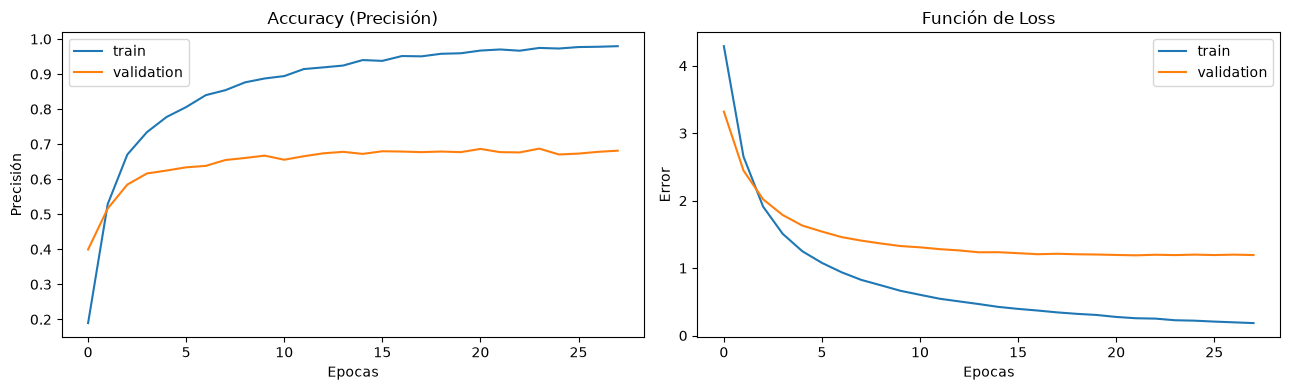

,accuracy,loss,val_accuracy,val_loss
0,0.189364,4.290186,0.399500,3.320072
1,0.528884,2.652957,0.516264,2.446589
2,0.670282,1.911249,0.584654,2.019502
3,0.734307,1.507533,0.616347,1.786550
4,0.777477,1.249444,0.624687,1.630252
5,0.805839,1.076967,0.633862,1.541353
6,0.839833,0.937941,0.638032,1.459531
7,0.854015,0.825264,0.654712,1.407317
8,0.876329,0.745154,0.660550,1.364829
9,0.887383,0.663445,0.667223,1.326723


In [6]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    #ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

history_df = plot_training_history(history)
display(history_df)


## 8. Fine-Tuning

Solo se ejecuta si `MODO == "finetuning"`. Partiendo de la cabeza ya entrenada en la fase 1, descongelamos el backbone (`base_model.trainable = True`) y volvemos a congelar las primeras `FINETUNE_FREEZE_LAYERS` capas, dejando entrenables solo las mas altas (de `block6` en adelante). Recompilamos con un learning rate bajo (`FINETUNE_LR`) y continuamos con `initial_epoch` para que las epocas sigan la numeracion de la fase 1.

Las capas `BatchNormalization` se mantienen en modo inferencia gracias al `training=False` con que llamamos al `base_model` en la celda 6, asi que no hace falta congelarlas una por una.

In [ ]:
if HACER_FINETUNING:
    # Descongelamos el base y volvemos a congelar las primeras N capas.
    base_model.trainable = True
    for layer in base_model.layers[:FINETUNE_FREEZE_LAYERS]:
        layer.trainable = False

    # con que llamamos al base en la celda 6, asi que no hace falta congelarlas a mano.
    model.compile(
        optimizer=Adam(learning_rate=FINETUNE_LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=history.epoch[-1] + 1,
        epochs=history.epoch[-1] + 1 + FINETUNE_EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    plot_training_history(history_ft)


## 9. Evaluacion directa en conjunto de prueba


In [7]:
test_metrics = model.evaluate(test_ds, verbose=1)

print("Metricas en conjunto de prueba:")
for name, value in zip(model.metrics_names, test_metrics):
    print(f"{name}: {value:.4f}")


363/363 ━━━━━━━━━━━━━━━━━━━━ 60s 165ms/step - accuracy: 0.6966 - loss: 1.1140
Metricas en conjunto de prueba:
loss: 1.1140
compile_metrics: 0.6966


## 10. Matriz de confusion y reporte de clasificacion


In [8]:
# test_ds no esta barajado; asi y_true y y_pred quedan alineados.
y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
y_pred = model.predict(test_ds, verbose=1).argmax(axis=1)

test_accuracy_from_predictions = np.mean(y_true == y_pred)
print(f"Accuracy en test ({model.name}): {test_accuracy_from_predictions:.4f}")

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report).transpose()
display(report_df)


2026-06-30 18:36:16.887113: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


363/363 ━━━━━━━━━━━━━━━━━━━━ 47s 99ms/step
Accuracy en test (EfficientNetB2_transfer_learning): 0.6966


,precision,recall,f1-score,support
0,0.920000,0.766667,0.836364,30.000000
1,0.913043,0.700000,0.792453,30.000000
2,0.627907,0.964286,0.760563,28.000000
3,0.805556,0.966667,0.878788,30.000000
4,0.923077,0.857143,0.888889,14.000000
...,...,...,...,...
198,0.800000,0.800000,0.800000,30.000000
199,0.833333,0.833333,0.833333,30.000000
accuracy,0.696583,0.696583,0.696583,0.696583
macro avg,0.714443,0.700090,0.700601,5794.000000


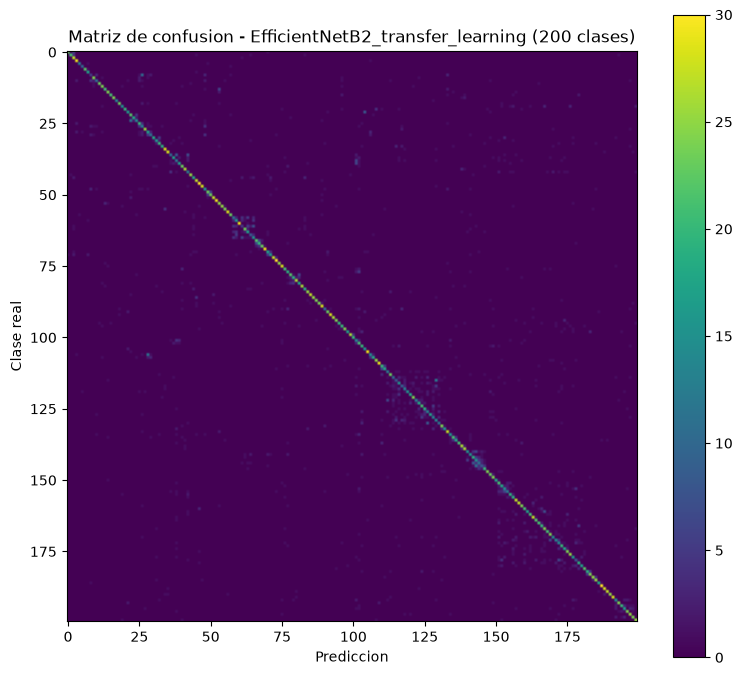

Top 10 pares mas confundidos:
  '115' confundida con '129': 12 veces
  '145' confundida con '143': 11 veces
  '106' confundida con '28': 11 veces
  '24' confundida con '22': 11 veces
  '8' confundida con '26': 10 veces
  '144' confundida con '142': 8 veces
  '130' confundida con '126': 8 veces
  '36' confundida con '38': 8 veces
  '21' confundida con '104': 8 veces
  '161' confundida con '167': 7 veces


In [9]:
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="viridis")
plt.title(f"Matriz de confusion - {model.name} ({len(class_names)} clases)")
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_sin_diagonal = cm.copy()
np.fill_diagonal(cm_sin_diagonal, 0)

pares_confundidos = [
    (cm_sin_diagonal[i, j], i, j)
    for i in range(len(cm_sin_diagonal))
    for j in range(len(cm_sin_diagonal))
    if cm_sin_diagonal[i, j] > 0
]
pares_confundidos.sort(reverse=True)

print("Top 10 pares mas confundidos:")
for cantidad, real_idx, pred_idx in pares_confundidos[:10]:
    print(f"  '{class_names[real_idx]}' confundida con '{class_names[pred_idx]}': {cantidad} veces")


## 10.b Diccionario indice -> clase

Construimos un diccionario `idx_to_class` que mapea cada entero a su nombre de clase para saber a que especie corresponde cada indice. Esta celda **no depende del modelo entrenado**: usa `class_names` (definido al cargar el dataset) y `pares_confundidos` (de la matriz de confusion), por lo que se puede ejecutar sin volver a correr el entrenamiento.

In [ ]:
# Diccionario indice -> nombre de clase para interpretar los enteros de la matriz de confusion.
# Solo depende de `class_names` y `pares_confundidos`, por lo que se puede correr sin reentrenar.
idx_to_class = dict(enumerate(class_names))

# Nos quedamos con las clases que aparecen en el top de pares mas confundidos.
top_n = 10
indices_confundidos = sorted(
    {i for _, real_idx, pred_idx in pares_confundidos[:top_n] for i in (real_idx, pred_idx)}
)
clases_confundidas = {idx: idx_to_class[idx] for idx in indices_confundidos}

print(f"Clases involucradas en el top {top_n} de pares confundidos:")
for idx, nombre in clases_confundidas.items():
    print(f"  {idx}: {nombre}")


## 11. Guardar resultados y modelo


In [10]:
# History completo: fase 1 (+ fase 2 de fine-tuning si corresponde).
frames = [pd.DataFrame(history.history)]
if HACER_FINETUNING:
    frames.append(pd.DataFrame(history_ft.history))
history_full_df = pd.concat(frames, ignore_index=True)

results = {
    "modelo": "EfficientNetB2",
    "modo": MODO,
    "dataset": DATASET_NAME,
    "train_split": TRAIN_SPLIT,
    "val_split": VAL_SPLIT,
    "test_split": TEST_SPLIT,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "augmentation": USAR_AUGMENTATION,
    "epochs_configuradas": EPOCHS,
    "epochs_ejecutadas": len(history_full_df),
    "learning_rate": LEARNING_RATE,
    "finetune_lr": FINETUNE_LR if HACER_FINETUNING else None,
    "finetune_freeze_layers": FINETUNE_FREEZE_LAYERS if HACER_FINETUNING else None,
    "test_loss": test_metrics[0],
    "test_accuracy": test_metrics[1],
}

results_df = pd.DataFrame([results])
display(results_df)

results_path = RESULTS_DIR / f"efficientnetb2_{MODO}_results.csv"
history_path = RESULTS_DIR / f"efficientnetb2_{MODO}_history.csv"
preds_path = RESULTS_DIR / f"efficientnetb2_{MODO}_preds.csv"
model_path = MODELS_DIR / f"efficientnetb2_{MODO}.keras"

results_df.to_csv(results_path, index=False)
history_full_df.to_csv(history_path, index=False)
# Predicciones por muestra del test: con esto se regenera la matriz de confusion,
# el reporte por clase y los pares confundidos sin volver a correr el modelo.
pd.DataFrame({"y_true": y_true, "y_pred": y_pred}).to_csv(preds_path, index=False)
model.save(model_path)

# class_names es el mismo para todas las corridas; lo guardamos una sola vez para
# que el notebook de comparacion pueda etiquetar las clases sin cargar tfds.
class_names_path = RESULTS_DIR / "class_names.csv"
if not class_names_path.exists():
    pd.DataFrame({"idx": range(len(class_names)), "clase": class_names}).to_csv(
        class_names_path, index=False
    )

print("Resultados guardados en:", results_path)
print("History guardado en:", history_path)
print("Predicciones guardadas en:", preds_path)
print("Modelo guardado en:", model_path)

,modelo,modo,dataset,train_split,val_split,test_split,img_size,batch_size,augmentation,epochs_configuradas,epochs_ejecutadas,learning_rate,finetune_lr,finetune_freeze_layers,test_loss,test_accuracy
0,EfficientNetB2,transfer_learning,caltech_birds2011,train[:80%],train[80%:],test,260,16,False,30,28,0.0005,None,None,1.113958,0.696583


Resultados guardados en: /home/felipe_r/proyectos/TP3-CNN/resultados/efficientnetb2_transfer_learning_results.csv
History guardado en: /home/felipe_r/proyectos/TP3-CNN/resultados/efficientnetb2_transfer_learning_history.csv
Predicciones guardadas en: /home/felipe_r/proyectos/TP3-CNN/resultados/efficientnetb2_transfer_learning_preds.csv
Modelo guardado en: /home/felipe_r/proyectos/TP3-CNN/modelos_guardados/efficientnetb2_transfer_learning.keras
